In [2]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np


In [3]:
X,y=make_regression(n_samples=4,n_features=1,n_targets=1,noise=100,random_state=13)

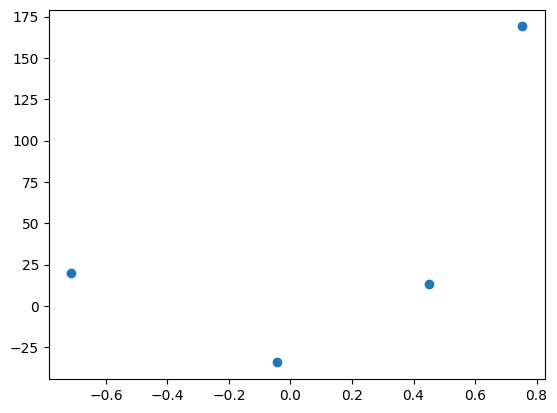

In [4]:
plt.scatter(X,y)

In [5]:
from sklearn.linear_model import LinearRegression


In [6]:
reg=LinearRegression()
reg.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[82.71]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,32.7
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[1.11]


In [7]:
m=reg.coef_

In [8]:
reg.intercept_

np.float64(32.69954105391578)

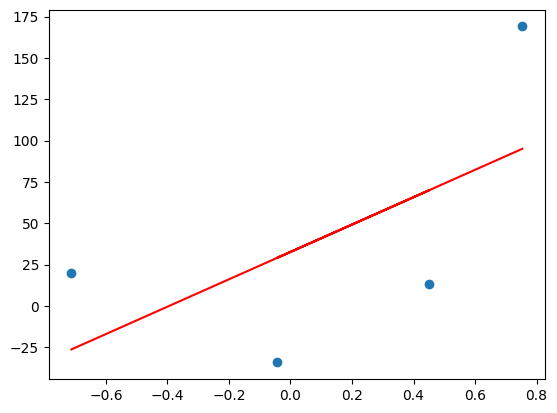

In [9]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red')

In [10]:
y_pred=((m*X)+100).reshape(4)

In [11]:
y_pred.shape

(4,)

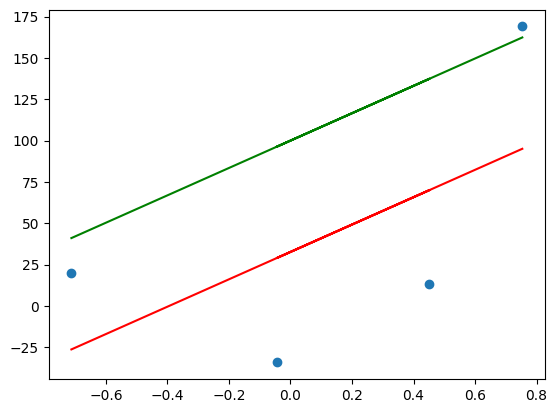

In [12]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color="red",label='OLS')
plt.plot(X,y_pred,color='green',label='b=100')

In [13]:
X

array([[-0.71239066],
       [ 0.45181234],
       [-0.04450308],
       [ 0.75376638]])

In [14]:
X.ravel()

array([-0.71239066,  0.45181234, -0.04450308,  0.75376638])

In [18]:
b=100

In [15]:
loss_slope=-2*np.sum(y-m*X.ravel()-100)
loss_slope

np.float64(538.4036715686738)

In [16]:
lr=0.1
step_size=lr*loss_slope
step_size

np.float64(53.84036715686738)

In [19]:
b=b-step_size

In [20]:
b

np.float64(46.15963284313262)

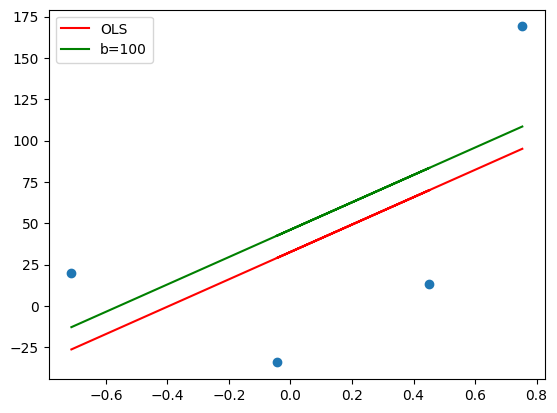

In [21]:
y_pred1=((m*X)+b).reshape(4)

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color="red",label='OLS')
plt.plot(X,y_pred1,color='green',label='b=100')
plt.legend()
plt.show()

In [22]:
#iteration2

loss_slope=-2*np.sum(y-m*X.ravel()-b)
loss_slope

np.float64(107.68073431373476)

In [23]:
step_size=lr*loss_slope
step_size

np.float64(10.768073431373477)

In [24]:
b=b-step_size
b

np.float64(35.39155941175915)

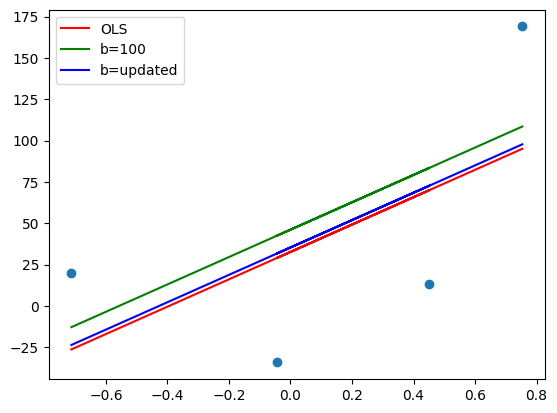

In [25]:
y_pred2=((m*X)+b).reshape(4)

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color="red",label='OLS')
plt.plot(X,y_pred1,color='green',label='b=100')
plt.plot(X,y_pred2,color='blue',label='b=updated')
plt.legend()
plt.show()

In [26]:
loss_slope=-2*np.sum(y-m*X.ravel()-b)
loss_slope

np.float64(21.53614686274696)

In [27]:
step_size=lr*loss_slope
step_size

np.float64(2.1536146862746963)

In [28]:
b=b-step_size
b

np.float64(33.237944725484454)

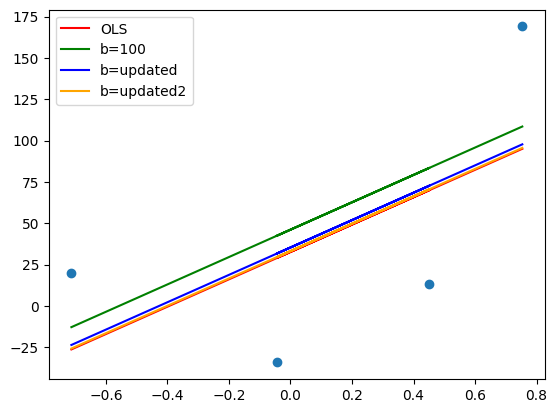

In [29]:
y_pred3=((m*X)+b).reshape(4)
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color="red",label='OLS')
plt.plot(X,y_pred1,color='green',label='b=100')
plt.plot(X,y_pred2,color='blue',label='b=updated')
plt.plot(X,y_pred3,color='orange',label='b=updated2')
plt.legend()
plt.show()

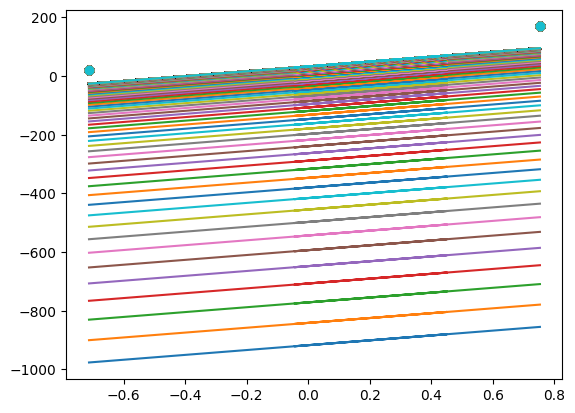

In [30]:
b=-1000
lr=0.01
epochs=1000
for i in range(epochs):
    loss_slope=-2*np.sum(y-m*X.ravel()-b)
    b=b-(lr*loss_slope)
    y_pred=(m*X)+b
    plt.scatter(X,y)
    plt.plot(X,y_pred)